In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import scipy.sparse as sp
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

with open(PROCESSED / "model_artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

encoder = artifacts["encoder"]
model = artifacts["xgb"]
CLASSES = artifacts["classes"]
CATEGORICAL = artifacts["categorical"]
NUMERIC = artifacts["numeric"]

test_sample = pd.read_parquet(PROCESSED / "test_sample.parquet")
print("Test sample:", test_sample.shape)

Test sample: (100000, 21)


In [2]:
# TreeSHAP is exact but still costly, so we explain a few thousand shots
# rather than the full test set. The estimates are stable at this size.
SHAP_SAMPLE = 5000
explain_data = test_sample.sample(SHAP_SAMPLE, random_state=42)

for col in CATEGORICAL:
    explain_data[col] = explain_data[col].fillna("none").astype(str)
for col in NUMERIC:
    explain_data[col] = explain_data[col].fillna(0).astype(float)

X_explain = sp.hstack([encoder.transform(explain_data[CATEGORICAL]),
                       sp.csr_matrix(explain_data[NUMERIC].values)]).tocsr()

# Readable names for the one-hot columns, so plots show "direction_pattern_
# down_the_line" instead of an index number.
feature_names = list(encoder.get_feature_names_out(CATEGORICAL)) + NUMERIC

X_dense = pd.DataFrame(X_explain.toarray(), columns=feature_names)
print("Explaining", X_dense.shape[0], "shots with", X_dense.shape[1], "features")

Explaining 5000 shots with 76 features


In [3]:
# Shapley values distribute the model's output among the features in the
# only way satisfying efficiency, symmetry, dummy and additivity.
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_dense)

print("SHAP output shape:", np.array(shap_values).shape)

SHAP output shape: (5000, 76, 4)


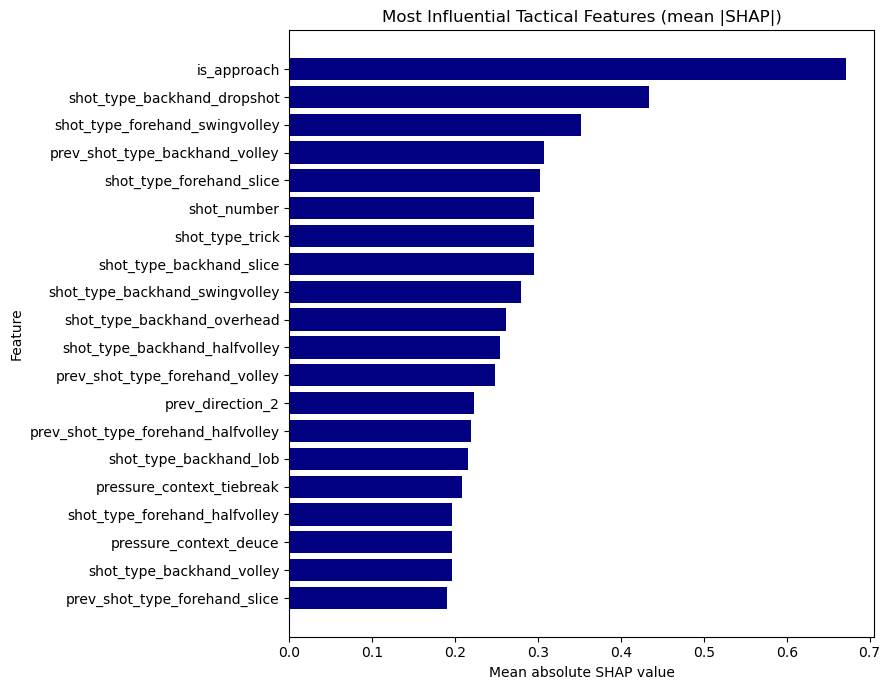

In [4]:
# Mean absolute SHAP value per feature, summed across the four classes.
shap_array = np.array(shap_values)
if shap_array.ndim == 3 and shap_array.shape[0] != len(CLASSES):
    shap_array = np.transpose(shap_array, (2, 0, 1))

importance = np.abs(shap_array).mean(axis=(0, 1))
top = pd.Series(importance, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
plt.barh(top.index[::-1], top.values[::-1], color="navy")
plt.title("Most Influential Tactical Features (mean |SHAP|)")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES / "shap_importance_overall.png", dpi=150)
plt.show()

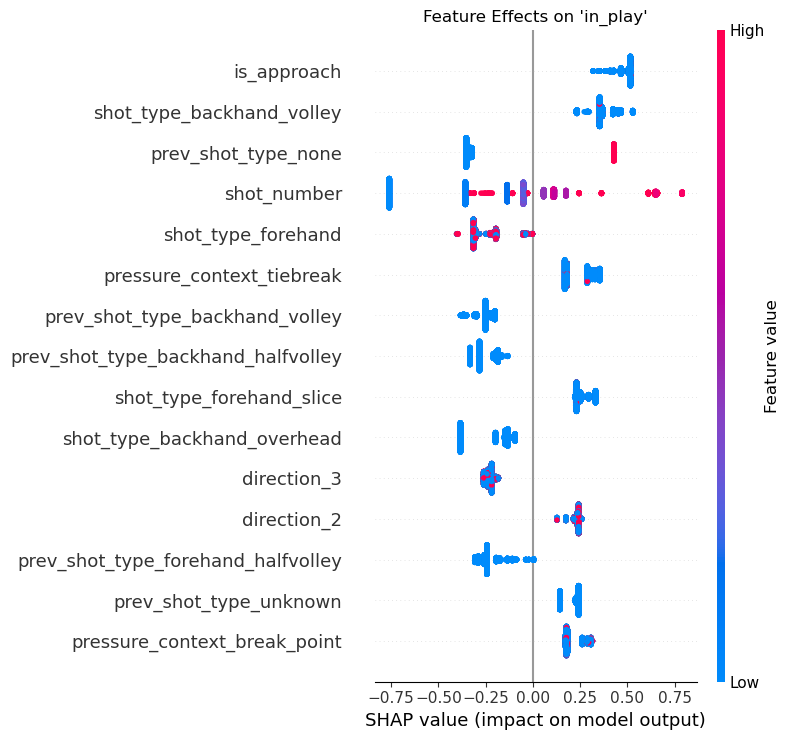

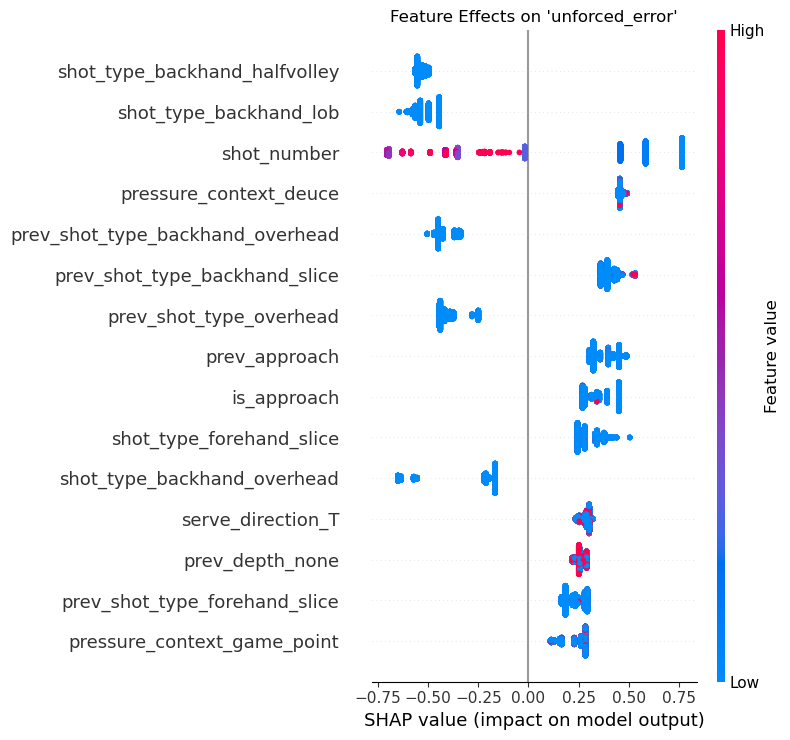

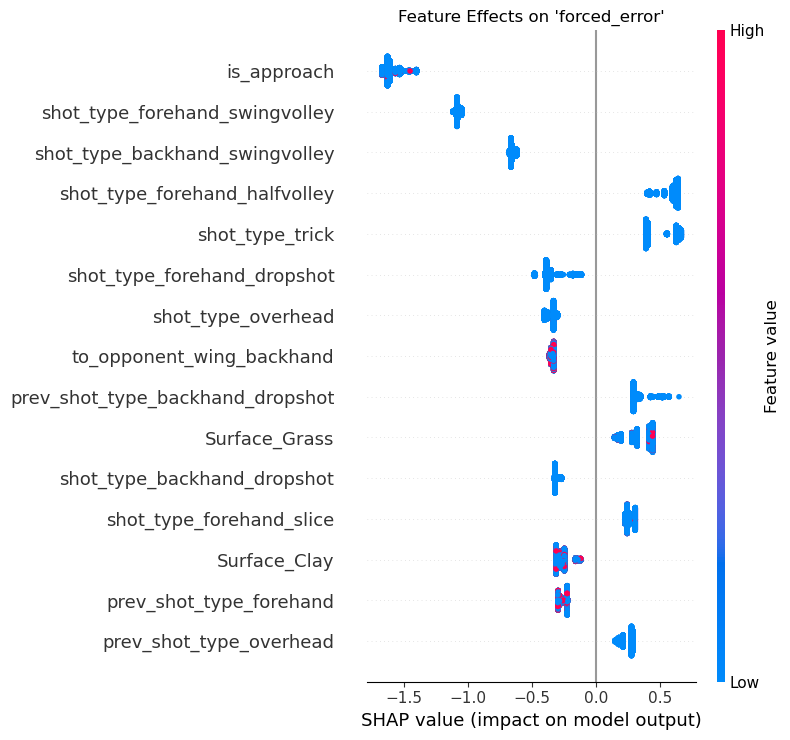

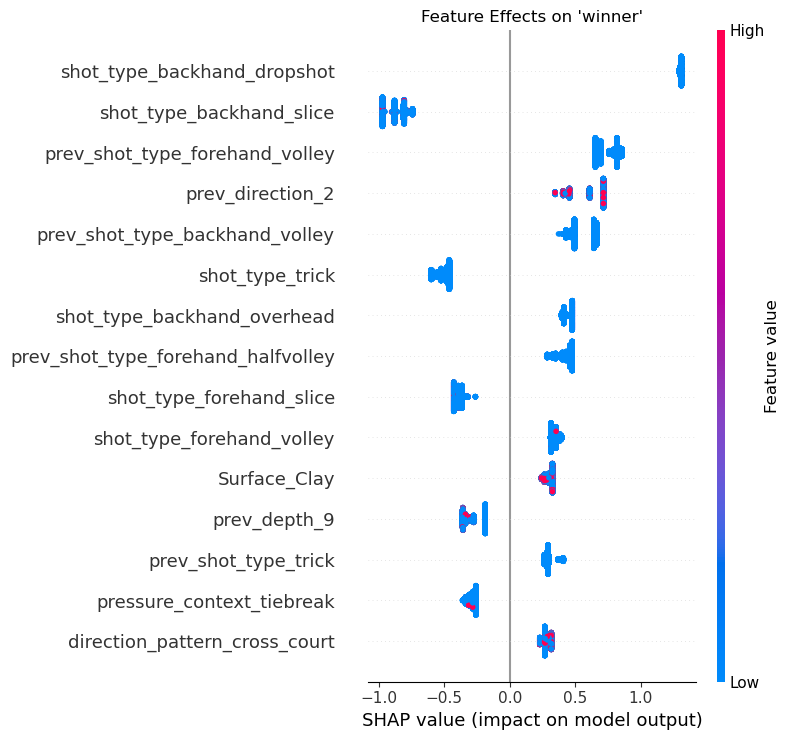

In [5]:
# This is the direct answer to the main research question: for each outcome,
# which tactical choices push its probability up or down.
for class_index, class_name in enumerate(CLASSES):
    plt.figure()
    shap.summary_plot(shap_array[class_index], X_dense,
                      max_display=15, show=False)
    plt.title(f"Feature Effects on '{class_name}'")
    plt.tight_layout()
    plt.savefig(FIGURES / f"shap_summary_{class_name}.png", dpi=150,
                bbox_inches="tight")
    plt.show()

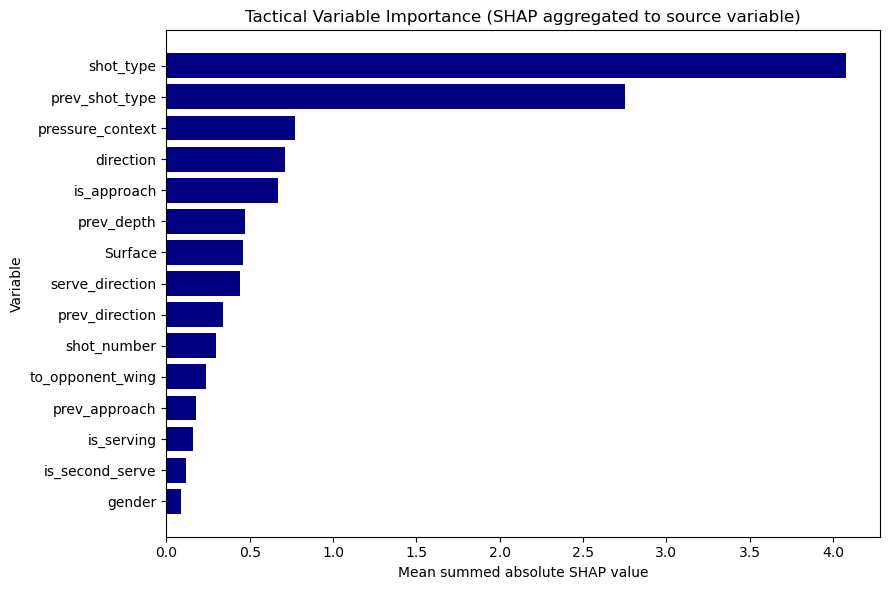

shot_type           4.079
prev_shot_type      2.753
pressure_context    0.774
direction           0.711
is_approach         0.671
prev_depth          0.469
Surface             0.457
serve_direction     0.444
prev_direction      0.341
shot_number         0.295
to_opponent_wing    0.237
prev_approach       0.179
is_serving          0.161
is_second_serve     0.119
gender              0.089


In [6]:
# One-hot encoding split 11 variables into 76 columns, so per-column SHAP
# answers "which category matters", not "which variable matters". Summing the
# columns belonging to each original variable restores the intended question,
# and naturally accounts for frequency: a rare category contributes to the
# variable's total only on the few rows where it is active.
column_to_variable = {}
for col in feature_names:
    parent = next((c for c in CATEGORICAL if col.startswith(c + "_")), col)
    column_to_variable[col] = parent

# Per row, sum the absolute SHAP of all columns from the same variable,
# then average across rows and classes.
variable_importance = {}
for variable in dict.fromkeys(column_to_variable.values()):
    cols = [i for i, c in enumerate(feature_names)
            if column_to_variable[c] == variable]
    per_row = np.abs(shap_array[:, :, cols]).sum(axis=2)
    variable_importance[variable] = per_row.mean()

importance_series = pd.Series(variable_importance).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_series.index[::-1], importance_series.values[::-1],
         color="navy")
plt.title("Tactical Variable Importance (SHAP aggregated to source variable)")
plt.xlabel("Mean summed absolute SHAP value")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(FIGURES / "shap_importance_by_variable.png", dpi=150)
plt.show()

print(importance_series.round(3).to_string())

In [8]:
import seaborn as sns
sns.set_style("whitegrid")

Shots used: 3796


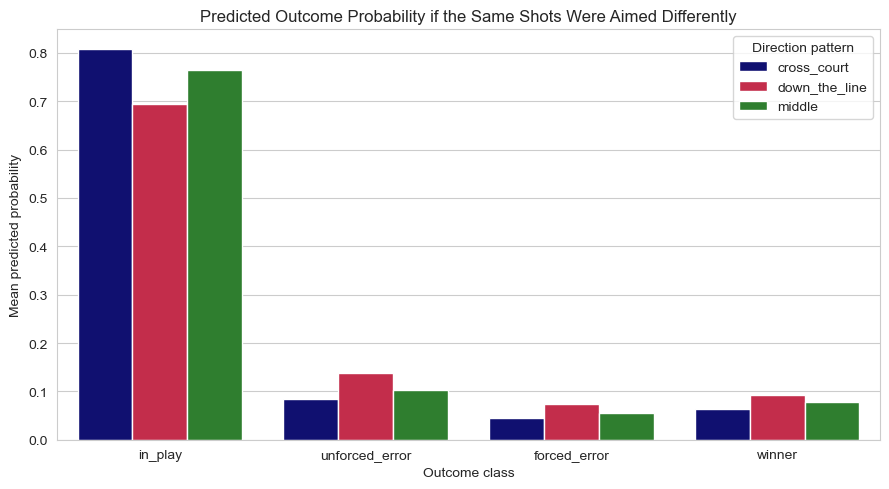

outcome        forced_error  in_play  unforced_error  winner
pattern                                                     
cross_court          0.0444   0.8083          0.0844  0.0629
down_the_line        0.0748   0.6938          0.1385  0.0929
middle               0.0545   0.7654          0.1021  0.0780


In [13]:
# SHAP attributes a prediction to features; it does not answer "what if this
# shot had been aimed elsewhere". That question is counterfactual, so we ask
# it directly: take the same shots, overwrite only the direction pattern,
# and re-predict. Everything else - rally position, incoming ball, shot type,
# surface, pressure - stays fixed, so the difference isolates the choice.
PATTERNS = ["cross_court", "down_the_line", "middle"]

# Only rally shots can have a direction pattern; the return (shot 2) cannot.
counterfactual_base = explain_data[explain_data["direction_pattern"] != "none"].copy()
print("Shots used:", len(counterfactual_base))

rows = []
for pattern in PATTERNS:
    scenario = counterfactual_base.copy()
    scenario["direction_pattern"] = pattern

    X_scenario = sp.hstack([encoder.transform(scenario[CATEGORICAL]),
                            sp.csr_matrix(scenario[NUMERIC].values)]).tocsr()
    predicted = model.predict_proba(X_scenario)

    for class_index, class_name in enumerate(CLASSES):
        rows.append({"pattern": pattern, "outcome": class_name,
                     "probability": predicted[:, class_index].mean()})

counterfactual = pd.DataFrame(rows)

plt.figure(figsize=(9, 5))
sns.barplot(data=counterfactual, x="outcome", y="probability", hue="pattern",
            palette=["navy", "crimson", "forestgreen"])
plt.title("Predicted Outcome Probability if the Same Shots Were Aimed Differently")
plt.xlabel("Outcome class")
plt.ylabel("Mean predicted probability")
plt.legend(title="Direction pattern")
plt.tight_layout()
plt.savefig(FIGURES / "counterfactual_direction.png", dpi=150)
plt.show()

table = counterfactual.pivot(index="pattern", columns="outcome", values="probability")
print(table.round(4).to_string())

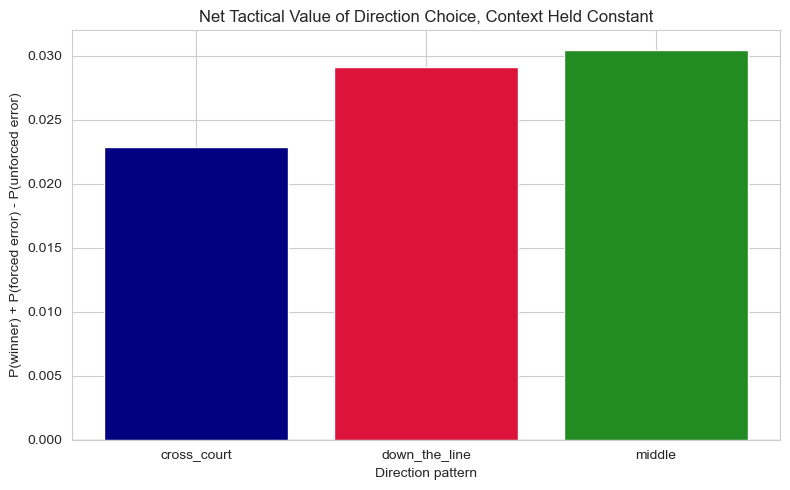

outcome        forced_error  in_play  unforced_error  winner  net_value
pattern                                                                
cross_court          0.0444   0.8083          0.0844  0.0629     0.0229
down_the_line        0.0748   0.6938          0.1385  0.0929     0.0292
middle               0.0545   0.7654          0.1021  0.0780     0.0305

Raw EDA net value (no context control):
  cross_court    +0.021
  down_the_line  +0.092


In [14]:
# Net tactical value: outcomes that win the point minus the one that loses it.
table["net_value"] = (table["winner"] + table["forced_error"]
                      - table["unforced_error"])

plt.figure(figsize=(8, 5))
plt.bar(table.index, table["net_value"],
        color=["navy", "crimson", "forestgreen"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Net Tactical Value of Direction Choice, Context Held Constant")
plt.xlabel("Direction pattern")
plt.ylabel("P(winner) + P(forced error) - P(unforced error)")
plt.tight_layout()
plt.savefig(FIGURES / "counterfactual_net_value.png", dpi=150)
plt.show()

print(table.round(4).to_string())

# The raw EDA comparison, for contrast.
print("\nRaw EDA net value (no context control):")
print("  cross_court    +0.021")
print("  down_the_line  +0.092")